# Reusable Embeddings

**Learning Objectives**
1. Learn how to use a pre-trained TF Hub text modules to generate sentence vectors.
1. Learn how to incorporate a pre-trained TF-Hub module into a Keras model.


## Introduction


In this notebook, we will implement text models to recognize the probable source (Github, Tech-Crunch, or The New-York Times) of the titles we have in the title dataset.

First, we will load and pre-process the texts and labels so that they are suitable to be fed to sequential Keras models with first layer being TF-hub pre-trained modules. Thanks to this first layer, we won't need to tokenize and integerize the text before passing it to our models. The pre-trained layer will take care of that for us, and consume directly raw text. However, we will still have to one-hot-encode each of the 3 classes into a 3 dimensional basis vector.

Then we will build, train and compare simple DNN models starting with different pre-trained TF-Hub layers.

In [1]:
# !pip install --upgrade "tensorflow==2.12.*" "tensorflow-hub==0.12.0" "keras==2.12.*"
# !pip install protobuf==3.20.3
# !pip install setuptools

In [2]:
import os

from google.cloud import bigquery
import pandas as pd

In [3]:
%load_ext google.cloud.bigquery

The google.cloud.bigquery extension is already loaded. To reload it, use:
  %reload_ext google.cloud.bigquery


Replace the variable values in the cell below:

In [4]:
PROJECT = "qwiklabs-gcp-01-0c29103a6825"  # Replace with your PROJECT
BUCKET = PROJECT 
REGION = "us-central1"

os.environ['PROJECT'] = PROJECT
os.environ['BUCKET'] = BUCKET
os.environ['REGION'] = REGION

## Create a Dataset from BigQuery 

Hacker news headlines are available as a BigQuery public dataset. The [dataset](https://bigquery.cloud.google.com/table/bigquery-public-data:hacker_news.stories?tab=details) contains all headlines from the sites inception in October 2006 until October 2015. 

Here is a sample of the dataset:

In [5]:
%%bigquery --project $PROJECT --use_rest_api
SELECT
    url, title, score
FROM
    `bigquery-public-data.hacker_news.full`
WHERE
    LENGTH(title) > 10
    AND score > 10
    AND LENGTH(url) > 0
LIMIT 10

Query is running:   0%|          |

Downloading:   0%|          |

,url,title,score
0,http://computationallegalstudies.com/2009/12/1...,"Movie: Visualizing Bank Failures, 2008 - 2009",11
1,http://devblogs.nvidia.com/parallelforall/gpus...,Faster Epidemic Forecasting on GPUs,11
2,http://www.ktvu.com/news/15054540/detail.html,Has E.T. Made A Call? (Possible Contact from I...,11
3,https://blog.mozilla.org/blog/2015/07/23/mdn-c...,MDN celebrates 10 years of documenting Your Web,11
4,http://www.newyorker.com/magazine/2015/07/27/t...,The Right Poem: When Pundits Refer to Plato,11
5,http://sethgodin.typepad.com/seths_blog/2009/1...,What Matters Now: get the free ebook,11
6,http://code.google.com/p/termite/,Termite : Erlang-style concurrency for Gambit ...,11
7,http://www.xconomy.com/boston/2009/12/14/sugar...,"Walter Bender on netbooks, e-books, and the ne...",11
8,http://money.cnn.com/2009/12/14/smallbusiness/...,Want to create jobs? Import entrepreneurs.,11
9,http://9lessons.blogspot.com/2009/12/twitter-l...,Twitter like Login with Jquery and CSS,11


Let's do some regular expression parsing in BigQuery to get the source of the newspaper article from the URL. For example, if the url is http://mobile.nytimes.com/...., I want to be left with <i>nytimes</i>

In [6]:
%%bigquery --project $PROJECT --use_rest_api

SELECT
    ARRAY_REVERSE(SPLIT(REGEXP_EXTRACT(url, '.*://(.[^/]+)/'), '.'))[SAFE_OFFSET(1)] AS source,
    COUNT(title) AS num_articles
FROM
    `bigquery-public-data.hacker_news.full`
WHERE
    REGEXP_CONTAINS(REGEXP_EXTRACT(url, '.*://(.[^/]+)/'), '.com$')
    AND LENGTH(title) > 10
GROUP BY
    source
ORDER BY num_articles DESC
LIMIT 100

Query is running:   0%|          |

Downloading:   0%|          |

,source,num_articles
0,github,210387
1,youtube,137853
2,medium,136696
3,nytimes,88527
4,blogspot,62817
...,...,...
95,nextplatform,3272
96,itworld,3162
97,atlasobscura,3122
98,oreilly,3042


Now that we have good parsing of the URL to get the source, let's put together a dataset of source and titles. This will be our labeled dataset for machine learning.

In [7]:
regex = '.*://(.[^/]+)/'


sub_query = """
SELECT
    title,
    ARRAY_REVERSE(SPLIT(REGEXP_EXTRACT(url, '{0}'), '.'))[safe_offset (1)] AS source
    
FROM
    `bigquery-public-data.hacker_news.full`
WHERE
    REGEXP_CONTAINS(REGEXP_EXTRACT(url, '{0}'), '.com$')
    AND LENGTH(title) > 10
""".format(regex)


query = """
SELECT 
    LOWER(REGEXP_REPLACE(title, '[^a-zA-Z0-9 $.-]', ' ')) AS title,
    source
FROM
  ({sub_query})
WHERE (source = 'github' OR source = 'nytimes' OR source = 'techcrunch')
""".format(sub_query=sub_query)

print(query)


SELECT 
    LOWER(REGEXP_REPLACE(title, '[^a-zA-Z0-9 $.-]', ' ')) AS title,
    source
FROM
  (
SELECT
    title,
    ARRAY_REVERSE(SPLIT(REGEXP_EXTRACT(url, '.*://(.[^/]+)/'), '.'))[safe_offset (1)] AS source

FROM
    `bigquery-public-data.hacker_news.full`
WHERE
    REGEXP_CONTAINS(REGEXP_EXTRACT(url, '.*://(.[^/]+)/'), '.com$')
    AND LENGTH(title) > 10
)
WHERE (source = 'github' OR source = 'nytimes' OR source = 'techcrunch')



For ML training, we usually need to split our dataset into training and evaluation datasets (and perhaps an independent test dataset if we are going to do model or feature selection based on the evaluation dataset). AutoML however figures out on its own how to create these splits, so we won't need to do that here. 



In [8]:
bq = bigquery.Client(project=PROJECT)
title_dataset = bq.query(query).to_dataframe()
title_dataset.head()

/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,title,source
0,a react renderer for the blessed library,github
1,robotjs node desktop automation,github
2,show hn full stack yeoman generator for angul...,github
3,show hn tastebin a pastebin with taste i.e....,github
4,embed the php interpreter in python,github


AutoML for text classification requires that
* the dataset be in csv form with 
* the first column being the texts to classify or a GCS path to the text 
* the last colum to be the text labels

The dataset we pulled from BiqQuery satisfies these requirements.

In [9]:
print("The full dataset contains {n} titles".format(n=len(title_dataset)))

The full dataset contains 359890 titles


Let's make sure we have roughly the same number of labels for each of our three labels:

In [10]:
title_dataset.source.value_counts()

source
github        210387
nytimes        88527
techcrunch     60976
Name: count, dtype: int64

Finally we will save our data, which is currently in-memory, to disk.

We will create a csv file containing the full dataset and another containing only 1000 articles for development.

**Note:** It may take a long time to train AutoML on the full dataset, so we recommend to use the sample dataset for the purpose of learning the tool. 


In [11]:
DATADIR = './data/'

if not os.path.exists(DATADIR):
    os.makedirs(DATADIR)

In [12]:
FULL_DATASET_NAME = 'titles_full.csv'
FULL_DATASET_PATH = os.path.join(DATADIR, FULL_DATASET_NAME)

# Let's shuffle the data before writing it to disk.
title_dataset = title_dataset.sample(n=len(title_dataset))

title_dataset.to_csv(
    FULL_DATASET_PATH, header=False, index=False, encoding='utf-8')

Now let's sample 1000 articles from the full dataset and make sure we have enough examples for each label in our sample dataset (see [here](https://cloud.google.com/natural-language/automl/docs/beginners-guide) for further details on how to prepare data for AutoML).

In [13]:
sample_title_dataset = title_dataset.sample(n=1000)
sample_title_dataset.source.value_counts()

source
github        570
nytimes       262
techcrunch    168
Name: count, dtype: int64

Let's write the sample datatset to disk.

In [14]:
SAMPLE_DATASET_NAME = 'titles_sample.csv'
SAMPLE_DATASET_PATH = os.path.join(DATADIR, SAMPLE_DATASET_NAME)

sample_title_dataset.to_csv(
    SAMPLE_DATASET_PATH, header=False, index=False, encoding='utf-8')

In [17]:
import os
# Force TensorFlow to use the legacy Keras 2 behavior
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import sys

# Workaround for the pkg_resources issue in Python 3.12
try:
    import pkg_resources
except ImportError:
    import pip._vendor.pkg_resources as pkg_resources
    sys.modules["pkg_resources"] = pkg_resources

import tensorflow as tf
import tensorflow_hub as hub
import db_dtypes
from tf_keras import Sequential
from tf_keras.layers import Dense, Input

print("✅ Environment successfully configured!")

✅ Environment successfully configured!


In [18]:
import datetime
import os
import shutil

import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from tensorflow_hub import KerasLayer
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical


print(tf.__version__)

2.21.0


In [19]:
%matplotlib inline

Let's start by specifying where the information about the trained models will be saved as well as where our dataset is located:

In [20]:
MODEL_DIR = "./text_models"
DATA_DIR = "./data"

## Loading the dataset

As in the previous labs, our dataset consists of titles of articles along with the label indicating from which source these articles have been taken from (GitHub, Tech-Crunch, or the New-York Times):

In [21]:
ls ./data/

titles_full.csv  titles_sample.csv


In [22]:
DATASET_NAME = "titles_full.csv"
TITLE_SAMPLE_PATH = os.path.join(DATA_DIR, DATASET_NAME)
COLUMNS = ['title', 'source']

titles_df = pd.read_csv(TITLE_SAMPLE_PATH, header=None, names=COLUMNS)
titles_df.head()

,title,source
0,ring 2.0 draft specification,github
1,a.i. is getting better at mind-reading,nytimes
2,anonymous vows revenge for hebdo massacre,techcrunch
3,move loot yc w14 brings furniture consignmen...,techcrunch
4,google wallet now lets you singletap that app,techcrunch


Let's look again at the number of examples per label to make sure we have a well-balanced dataset:

In [23]:
titles_df.source.value_counts()

source
github        210387
nytimes        88527
techcrunch     60976
Name: count, dtype: int64

## Preparing the labels

In this lab, we will use pre-trained [TF-Hub embeddings modules for english](https://tfhub.dev/s?q=tf2%20embeddings%20text%20english) for the first layer of our models. One immediate
advantage of doing so is that the TF-Hub embedding module will take care for us of processing the raw text. 
This also means that our model will be able to consume text directly instead of sequences of integers representing the words.

However, as before, we still need to preprocess the labels into one-hot-encoded vectors:

In [24]:
CLASSES = {
    'github': 0,
    'nytimes': 1,
    'techcrunch': 2
}
N_CLASSES = len(CLASSES)

In [25]:
def encode_labels(sources):
    classes = [CLASSES[source] for source in sources]
    one_hots = to_categorical(classes, num_classes=N_CLASSES)
    return one_hots

In [26]:
encode_labels(titles_df.source[:4])

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]])

## Preparing the train/test splits

Let's split our data into train and test splits:

In [27]:
N_TRAIN = int(len(titles_df) * 0.95)

titles_train, sources_train = (
    titles_df.title[:N_TRAIN], titles_df.source[:N_TRAIN])

titles_valid, sources_valid = (
    titles_df.title[N_TRAIN:], titles_df.source[N_TRAIN:])

To be on the safe side, we verify that the train and test splits
have roughly the same number of examples per class.

Since it is the case, accuracy will be a good metric to use to measure
the performance of our models.

In [28]:
sources_train.value_counts()

source
github        199887
nytimes        84113
techcrunch     57895
Name: count, dtype: int64

In [29]:
sources_valid.value_counts()

source
github        10500
nytimes        4414
techcrunch     3081
Name: count, dtype: int64

Now let's create the features and labels we will feed our models with:

In [30]:
X_train, Y_train = titles_train.values, encode_labels(sources_train)
X_valid, Y_valid = titles_valid.values, encode_labels(sources_valid)

In [31]:
X_train[:3]

array(['ring 2.0 draft specification',
       'a.i. is getting better at mind-reading',
       ' anonymous  vows revenge for hebdo massacre'], dtype=object)

In [32]:
Y_train[:3]

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

## NNLM Model

We will first try a word embedding pre-trained using a [Neural Probabilistic Language Model](http://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf). TF-Hub has a 50-dimensional one called 
[nnlm-en-dim50-with-normalization](https://tfhub.dev/google/tf2-preview/nnlm-en-dim50/1), which also
normalizes the vectors produced. 

### Lab Task 1a: Import NNLM TF Hub module into `KerasLayer`

Once loaded from its url, the TF-hub module can be used as a normal Keras layer in a sequential or functional model. Since we have enough data to fine-tune the parameters of the pre-trained embedding itself, we will set `trainable=True` in the `KerasLayer` that loads the pre-trained embedding:

In [33]:
NNLM = "https://tfhub.dev/google/nnlm-en-dim50/2"

nnlm_module = KerasLayer(
    NNLM, output_shape=[50], input_shape=[], dtype=tf.string, trainable=True)

E0000 00:00:1778421270.932664    6981 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Note that this TF-Hub embedding produces a single 50-dimensional vector when passed a sentence:

### Lab Task 1b: Use module to encode a sentence string

In [34]:
nnlm_module(tf.constant(["The dog is happy to see people in the street."]))

<tf.Tensor: shape=(1, 50), dtype=float32, numpy=
array([[ 0.19331802,  0.05893906,  0.15330684,  0.2505918 ,  0.19369544,
         0.03578748,  0.07387847, -0.10962156, -0.11377034,  0.07172022,
         0.12458669, -0.02289705, -0.18177685, -0.07084437, -0.00225849,
        -0.36875236,  0.05772953, -0.14222091,  0.08765972, -0.14068899,
        -0.07005888, -0.20634466,  0.07220475,  0.04258814,  0.0955702 ,
         0.19424029, -0.42492998, -0.00706906, -0.02095   , -0.05055764,
        -0.18988201, -0.02841404,  0.13222624, -0.01459922, -0.31255388,
        -0.09577855,  0.05469003, -0.13858607,  0.01141668, -0.12352604,
        -0.07250367, -0.11605677, -0.06976165,  0.14313601, -0.15183711,
        -0.06836402,  0.03054246, -0.13259597, -0.14599673,  0.05094011]],
      dtype=float32)>

## Swivel Model

Then we will try a word embedding obtained using [Swivel](https://arxiv.org/abs/1602.02215), an algorithm that essentially factorizes word co-occurrence matrices to create the words embeddings. 
TF-Hub hosts the pretrained [gnews-swivel-20dim-with-oov](https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim-with-oov/1) 20-dimensional Swivel module.

### Lab Task 1c: Import Swivel TF Hub module into `KerasLayer`

In [35]:
# TODO
SWIVEL = "https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim-with-oov/1"
swivel_module = KerasLayer(
    SWIVEL, output_shape=[20], input_shape=[], dtype=tf.string, trainable=True)

Similarly as the previous pre-trained embedding, it outputs a single vector when passed a sentence:

### Lab Task 1d: Use module to encode a sentence string

In [36]:
swivel_module(tf.constant(["The dog is happy to see people in the street."]))

<tf.Tensor: shape=(1, 20), dtype=float32, numpy=
array([[ 0.9967701 , -0.3100155 ,  0.5889897 , -0.16765082, -0.6171738 ,
        -1.1586996 , -0.8619045 ,  0.7281645 ,  0.32575002,  0.4754492 ,
        -0.9272241 ,  0.41090095, -0.75389475, -0.31525993, -1.8918804 ,
         0.6423996 ,  0.6801622 , -0.1335669 , -1.0017993 , -0.11908641]],
      dtype=float32)>

## Building the models

Let's write a function that 

* takes as input an instance of a `KerasLayer` (i.e. the `swivel_module` or the `nnlm_module` we constructed above) as well as the name of the model (say `swivel` or `nnlm`)
* returns a compiled Keras sequential model starting with this pre-trained TF-hub layer, adding one or more dense relu layers to it, and ending with a softmax layer giving the probability of each of the classes:

### Lab Task 2: Incorporate a pre-trained TF Hub module as first layer of Keras Sequential Model

In [49]:
import os
import shutil

import pandas as pd

# Keep TF Hub and model code on the same Keras implementation.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as keras
from tf_keras.callbacks import TensorBoard, EarlyStopping
from tf_keras.layers import Dense
from tf_keras.models import Sequential
from tf_keras.utils import to_categorical

KerasLayer = hub.KerasLayer

print(tf.__version__)

2.21.0


In [50]:
# def build_model(hub_module, name):
#     model = Sequential([
#         hub_module, # TODO
#         Dense(16, activation='relu'),
#         Dense(N_CLASSES, activation='softmax')
#     ], name=name)

#     model.compile(
#         optimizer='adam',
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )
#     return model

def build_model(hub_module, name):
    model = keras.Sequential([
        hub.KerasLayer(
            hub_module,
            input_shape=[],
            dtype=tf.string,
            trainable=False
        ),
        Dense(16, activation="relu"),
        Dense(N_CLASSES, activation="softmax")
    ], name=name)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

Let's also wrap the training code into a `train_and_evaluate` function that 
* takes as input the training and validation data, as well as the compiled model itself, and the `batch_size`
* trains the compiled model for 100 epochs at most, and does early-stopping when the validation loss is no longer decreasing
* returns an `history` object, which will help us to plot the learning curves

In [51]:
def train_and_evaluate(train_data, val_data, model, batch_size=5000):
    X_train, Y_train = train_data

    tf.random.set_seed(33)

    model_dir = os.path.join(MODEL_DIR, model.name)
    if tf.io.gfile.exists(model_dir):
        tf.io.gfile.rmtree(model_dir)

    history = model.fit(
        X_train, Y_train,
        epochs=10,
        batch_size=batch_size,
        validation_data=val_data,
        callbacks=TensorBoard(model_dir),
    )
    return history

## Training NNLM

In [52]:
data = (X_train, Y_train)
val_data = (X_valid, Y_valid)

In [53]:
nnlm_model = build_model(nnlm_module, 'nnlm')
nnlm_history = train_and_evaluate(data, val_data, nnlm_model)


Got `type(handle)`: <class 'tensorflow_hub.keras_layer.KerasLayer'>



Got `type(handle)`: <class 'tensorflow_hub.keras_layer.KerasLayer'>


Epoch 1/10
69/69 [==============================] - 3s 26ms/step - loss: 0.9774 - accuracy: 0.5666 - val_loss: 0.8573 - val_accuracy: 0.6386
Epoch 2/10
69/69 [==============================] - 2s 22ms/step - loss: 0.7743 - accuracy: 0.6782 - val_loss: 0.7034 - val_accuracy: 0.7149
Epoch 3/10
69/69 [==============================] - 2s 22ms/step - loss: 0.6573 - accuracy: 0.7313 - val_loss: 0.6240 - val_accuracy: 0.7419
Epoch 4/10
69/69 [==============================] - 1s 21ms/step - loss: 0.6002 - accuracy: 0.7540 - val_loss: 0.5868 - val_accuracy: 0.7567
Epoch 5/10
69/69 [==============================] - 1s 20ms/step - loss: 0.5733 - accuracy: 0.7651 - val_loss: 0.5694 - val_accuracy: 0.7618
Epoch 6/10
69/69 [==============================] - 1s 21ms/step - loss: 0.5605 - accuracy: 0.7704 - val_loss: 0.5610 - val_accuracy: 0.7671
Epoch 7/10
69/69 [==============================] - 1s 20ms/step - loss: 0.5541 - accuracy: 0.7731 - val_loss: 0.5567 - val_accuracy: 0.7707
Epoch 8/10
69

<Axes: >

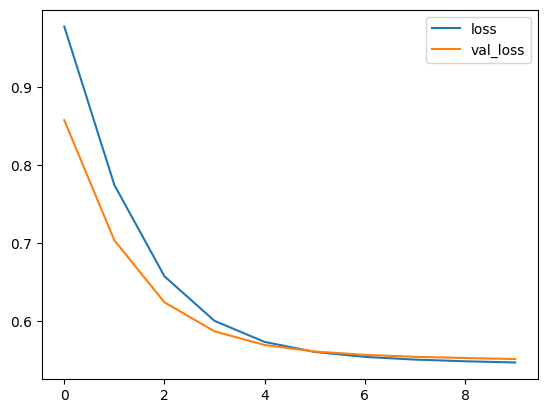

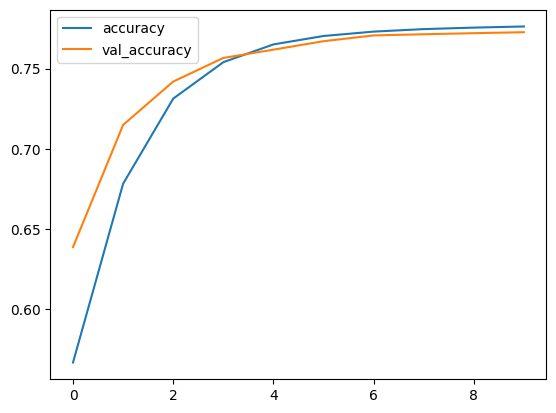

In [54]:
history = nnlm_history
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()

## Training Swivel

In [55]:
swivel_model = build_model(swivel_module, name='swivel')

In [56]:
swivel_history = train_and_evaluate(data, val_data, swivel_model)


Got `type(handle)`: <class 'tensorflow_hub.keras_layer.KerasLayer'>



Got `type(handle)`: <class 'tensorflow_hub.keras_layer.KerasLayer'>


Epoch 1/10
69/69 [==============================] - 2s 22ms/step - loss: 0.9511 - accuracy: 0.5987 - val_loss: 0.8546 - val_accuracy: 0.6471
Epoch 2/10
69/69 [==============================] - 1s 19ms/step - loss: 0.8114 - accuracy: 0.6650 - val_loss: 0.7791 - val_accuracy: 0.6758
Epoch 3/10
69/69 [==============================] - 1s 19ms/step - loss: 0.7647 - accuracy: 0.6832 - val_loss: 0.7501 - val_accuracy: 0.6861
Epoch 4/10
69/69 [==============================] - 1s 19ms/step - loss: 0.7458 - accuracy: 0.6902 - val_loss: 0.7367 - val_accuracy: 0.6897
Epoch 5/10
69/69 [==============================] - 1s 19ms/step - loss: 0.7362 - accuracy: 0.6939 - val_loss: 0.7290 - val_accuracy: 0.6930
Epoch 6/10
69/69 [==============================] - 1s 19ms/step - loss: 0.7300 - accuracy: 0.6964 - val_loss: 0.7241 - val_accuracy: 0.6954
Epoch 7/10
69/69 [==============================] - 1s 20ms/step - loss: 0.7253 - accuracy: 0.6981 - val_loss: 0.7198 - val_accuracy: 0.6974
Epoch 8/10
69

<Axes: >

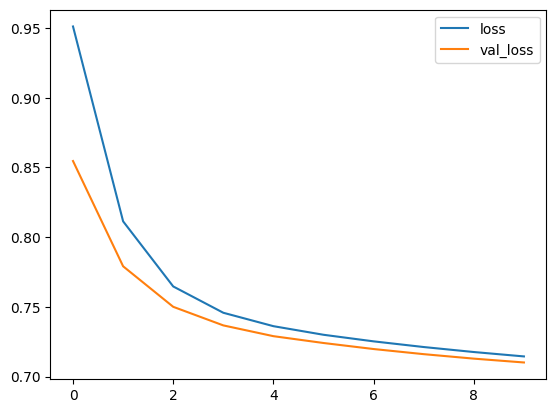

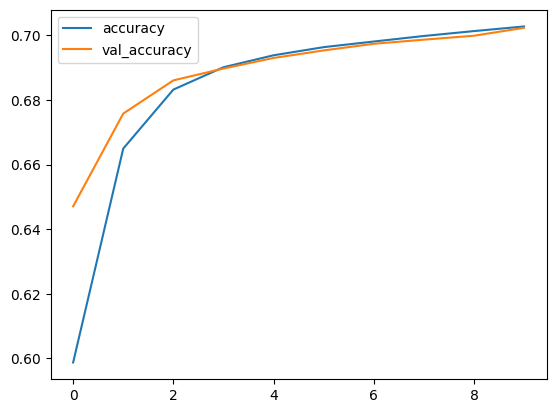

In [57]:
history = swivel_history
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()

Swivel trains faster but achieves a lower validation accuracy, and requires more epochs to train on.

## Bonus

Try to beat the best model by modifying the model architecture, changing the TF-Hub embedding, and tweaking the training parameters.

Copyright 2023 Google Inc. Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License